# **Constraching Technique**

**I(enhenced(x,y)) = [I(x,y)] - min(I)/max(I) - min(I)] * 255**

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# **Identify min(I) and max(I)**

1. method 1

In [2]:
# take image
I = np.array([[50,100,150],
              [200,75,125],
              [175,25,225]])

In [3]:
min_ = I.min()
max_ = I.max()
print(min_,max_)

25 225


2.method 2

In [ ]:
I = [[50,100,150],
     [200,75,125],
     [175,25,225]]

In [4]:
min_ = min(min_ for i in I)
max_ = max(max_ for i in I)
print(min_,max_)

25 225


# **Apply constrast streaching**

In [6]:
Ienhenced = [np.round((i - min_ / (max_ - min_)*255).astype(np.uint8)) for i in I]
print(Ienhenced)

[array([ 18,  68, 118], dtype=uint8), array([168,  43,  93], dtype=uint8), array([143, 250, 193], dtype=uint8)]


In [7]:
Ienhenced = [((i - min_)/(max_ - min_)*255) for i in I]
Ienhenced = np.round(Ienhenced).astype(np.uint8)
print(Ienhenced)

[[ 32  96 159]
 [223  64 128]
 [191   0 255]]


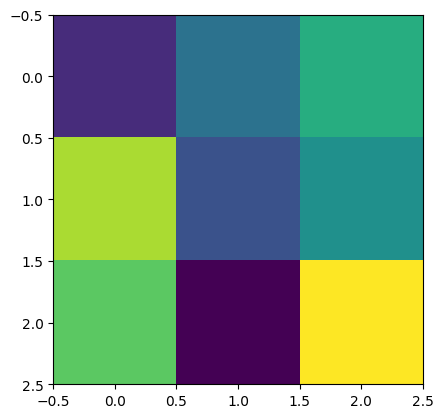

In [8]:
plt.imshow(Ienhenced)
plt.show()

In [10]:
matrix = [
    [50,100,150],
    [200,75,125],
    [175,25,225]
]

#find global min max
min_val = min(min(row) for row in matrix )
max_val = max(max(row) for row in matrix )

#avoid divison by zero
if max_val == min_val:
    enhanced = [[0 for _ in row] for row in matrix]
else:
    enhanced = [
        [
            int((element - min_val) / (max_val - min_val) *255 )
            for element in row
        ]
        for row in matrix
    ] 

print("enhanced matrix")
for row in enhanced:
    print(row)



enhanced matrix
[31, 95, 159]
[223, 63, 127]
[191, 0, 255]


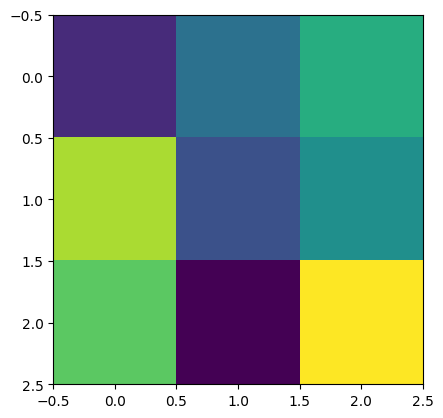

In [11]:
plt.imshow(enhanced)
plt.show()

# **Gamma Corelation Technique**

In [12]:
# matrix inisilization
I = [
    [50,100],
    [150,200]
]

**I(Enhenced = c * (I(x,y) ** r))**

In [ ]:
# read_I in gray_scale(I to image)
I = cv2.imread(I,cv2.IMREAD_GRAYSCALE)
#CONVERT to float and normalize to [0,1]
I = I.astype(np.float32) / 255.0
# parameters
c = 1.0 #scaling constant
r = 0.5 #gamma value(try >1 or <1)
# apply formula
enhenced = c*(I ** r)
#clip value [0,1]
enhenced = np.clip(enhenced,0,1)
#convert back to 0-255
enhenced = (enhenced * 255).astype(np.uint8)

#show result 
plt.imshow(enhenced,cmap = "gray")
plt.title("enhanced image")
plt.axis("off")
plt.show()

AttributeError: 'NoneType' object has no attribute 'astype'

# **Histogram Equliazton**

**I(enhanced)(x,y) = (L - 1) * sum(0 to I(x,y))**

In [24]:
matrix = [[52,55,61,59],
     [62,59,55,90],
     [63,59,55,90],
     [62,59,55,90]]

# **how to compute frequency**

In [25]:
I_freq = {}
for row in matrix:
    for element in row:
        I_freq[element] = I_freq.get(element,0) + 1
print(I_freq)


{52: 1, 55: 4, 61: 1, 59: 4, 62: 2, 90: 3, 63: 1}


**compute cummelitive frequency**

In [27]:
from collections import Counter
# flatten and count
flatted = [item for row in matrix for item in row]
freq_map = Counter(flatted)
print(freq_map)

# short key to enure freq order
sorted_key = sorted(freq_map.keys())
print(sorted_key)

#calculate cumalative frequency
cumm_freq = {}
running_total = 0
for key in sorted_key:
    running_total += freq_map[key]
    cumm_freq[key] = running_total
print(cumm_freq)



Counter({55: 4, 59: 4, 90: 3, 62: 2, 52: 1, 61: 1, 63: 1})
[52, 55, 59, 61, 62, 63, 90]
{52: 1, 55: 5, 59: 9, 61: 10, 62: 12, 63: 13, 90: 16}


# **gimini way**

In [28]:
#flatten img
flattened = [pixel for row in matrix for pixel in row]
total_pixels = len(flattened)

In [29]:
#2. Calculate Histogram (Frequency)
#Create a frequency map (dictionary) for every intensity value present.
hist = {}
for pixel in flattened:
    hist[pixel] = hist.get(pixel, 0) + 1

In [30]:
#3. Calculate Cumulative Frequency (CDF)
#Sort the intensities and find the running total of their frequencies.
sorted_intensities = sorted(hist.keys())
cdf = {}
running_sum = 0

for i in sorted_intensities:
    running_sum += hist[i]
    cdf[i] = running_sum

In [31]:
#4. Create the Transformation MapNormalize the CDF values to the standard pixel range ($0-255$).The formula used is: $h(v) = \text{round}\left(\frac{cdf(v) - cdf_{min}}{total\_pixels - cdf_{min}} \times 255\right)$Python
cdf_min = min(cdf.values())
transform_map = {}

for i in sorted_intensities:
    # Normalized scaling formula
    numerator = cdf[i] - cdf_min
    denominator = total_pixels - cdf_min
    
    if denominator == 0:
        transform_map[i] = 0
    else:
        transform_map[i] = round((numerator / denominator) * 255)

In [32]:
#5. Map the New Values
#Apply the transformation back to the original 2D matrix structure.
equalized_matrix = []
for row in matrix:
    new_row = [transform_map[pixel] for pixel in row]
    equalized_matrix.append(new_row)

print(equalized_matrix)

[[0, 68, 153, 136], [187, 136, 68, 255], [204, 136, 68, 255], [187, 136, 68, 255]]


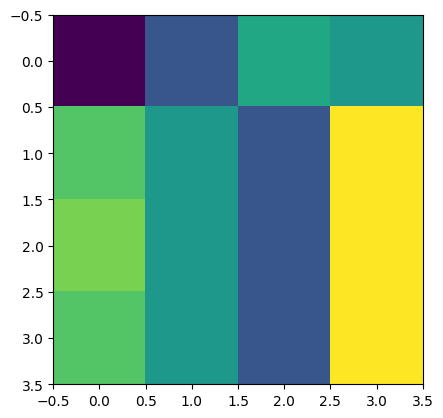

In [33]:
plt.imshow(equalized_matrix)